# Study 3: Platform as facilitator of sentiment and idea flow 
# Part 3: suggestion map

## Libraries

In [209]:
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

## Load and prepare data

In [217]:
# labelled reviews from part 2
labelled_reviews = pd.read_csv("labelled_reviews.csv", low_memory=False).drop_duplicates(subset=['review_user_id', 'gmap_id', 'review_text']).dropna(subset=['review_user_id'])

# geocodings from part 1 
reviews_geo = gpd.read_file("reviews_geo.geojson").drop_duplicates().dropna(subset=['review_user_id'])


In [219]:

muni_gdf = gpd.read_file("PA Municipality Boundaries_20260120.zip")

# Build unique ID from municipal_ + county
muni_gdf["muni_id"] = (
    muni_gdf["municipal_"].astype(str).str.strip().str.upper()
    + " | " +
    muni_gdf["county"].astype(str).str.strip().str.upper()
)

# Compute centroids in a metric CRS (3857), then back to lon/lat
muni_3857 = muni_gdf.to_crs(3857)
cent_4326 = muni_3857.geometry.centroid.to_crs(4326)

centroids = pd.DataFrame({
    "muni_id": muni_gdf["muni_id"].astype(str),
    "municipality_name": muni_gdf["municipal1"].astype(str),   # pretty label
    "lon": cent_4326.x.values,
    "lat": cent_4326.y.values,
}).set_index("muni_id")


In [220]:
len(labelled_reviews)

4386

## Check label shares

In [222]:
labelled_reviews["final_label"].value_counts()

final_label
NO       2682
MAYBE     957
YES       747
Name: count, dtype: int64

In [223]:
labelled_reviews["final_label"].value_counts(normalize=True)

final_label
NO       0.611491
MAYBE    0.218194
YES      0.170315
Name: proportion, dtype: float64

## Find users in the labelled dataset who made at least one suggestion (labelled YES)

In [224]:
users_with_yes = labelled_reviews[labelled_reviews['final_label'] == 'YES']['review_user_id'].astype(str).unique()

print("Users with ≥1 YES suggestion:", len(users_with_yes))

Users with ≥1 YES suggestion: 746


## Find municipalities with atleast one review with suggestion?

In [225]:
# merge into one dataframe to get municipality id
labelled_reviews= pd.merge(

labelled_reviews[["review_user_id", "gmap_id", "review_text", "rating", "has_response", "final_label"]],

reviews_geo[["review_user_id", "gmap_id", "review_date", "review_text", "rating", "has_response", "muni_id", "municipal1", "geometry"]],

on = ["review_user_id", "review_text", "gmap_id", "rating", "has_response"],

how = 'left'

)

In [226]:
len(labelled_reviews)

4386

In [227]:
#munis_with_yes = labelled_reviews[labelled_reviews["final_label"]=='YES'][["muni_id", "municipal1"]].astype(str).drop_duplicates()
munis_with_yes = labelled_reviews[labelled_reviews["final_label"]=='YES']["muni_id"].astype(str).unique()
print("Municipalities with ≥1 YES suggestion:", len(munis_with_yes))

Municipalities with ≥1 YES suggestion: 79


## Find all the inter-municipal transitions for the users with suggestions

In [228]:
selected_users_reviews = reviews_geo[reviews_geo["review_user_id"].astype(str).isin(users_with_yes)].copy()


# sort by time
selected_users_reviews["review_date"] = pd.to_datetime(selected_users_reviews["review_date"], errors="coerce")
selected_users_reviews = selected_users_reviews.sort_values(["review_user_id", "review_date"], na_position="last")


pairs = []
for uid, grp in selected_users_reviews.groupby("review_user_id", sort=False):
    seq = grp["muni_id"].dropna().astype(str).tolist()
    if len(seq) > 1:
        pairs += list(zip(seq[:-1], seq[1:]))

edges_yes = pd.DataFrame(pairs, columns=["from_id", "to_id"])
edges_yes = edges_yes[edges_yes["from_id"] != edges_yes["to_id"]]

edge_counts_yes = (
    edges_yes.groupby(["from_id","to_id"])
             .size()
             .reset_index(name="w")
             .sort_values("w", ascending=False)
)

print("Edges from users with YES suggestions:", len(edge_counts_yes))

Edges from users with YES suggestions: 186


## Create map

In [229]:
PAIR_RAD = 0.35
UNIDIR_RAD = 0.10
EDGE_COLOR = "red"
EDGE_ALPHA = 0.75
ARROW_SCALE = 10

DRAW_POLYGONS = True
POLY_EDGE_COLOR = "lightgray"
POLY_LINEWIDTH = 0.6

NODE_SIZE = 35
LABEL_TOP_N_NODES = 10
LABEL_FONTSIZE = 7

# -----------------------
# HELPERS
# -----------------------
def stable_pair_sign(a, b) -> int:
    s = str(a) + "||" + str(b)
    return 1 if (sum(ord(c) for c in s) % 2 == 0) else -1


def edge_rad(fid, tid):
    has_rev = (tid, fid) in edge_set_yes
    u, v = sorted((fid, tid))
    base = stable_pair_sign(u, v)
    if has_rev:
        return base * PAIR_RAD if fid == u else base * PAIR_RAD
    return base * UNIDIR_RAD

# Use the same mapping from weight -> linewidth
def weight_to_lw(w_value):
    return 0.6 + 2 * (w_value - weights.min()) / (weights.max() - weights.min() + 1e-9)

def draw_arc_arrow(ax, x1, y1, x2, y2, lw, rad, color="red", alpha=0.75):
    ax.add_patch(FancyArrowPatch(
        (float(x1), float(y1)), (float(x2), float(y2)),
        arrowstyle='-|>,head_length=0.4,head_width=0.3',
        mutation_scale=ARROW_SCALE,
        linewidth=float(lw),
        alpha=alpha,
        color=color,
        connectionstyle=f"arc3,rad={float(rad)}"
    ))

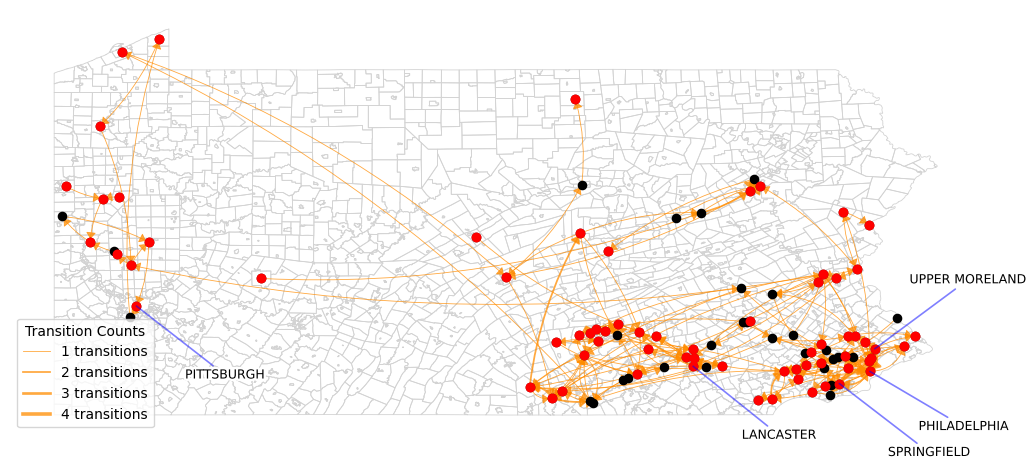

In [230]:
fig, ax = plt.subplots(figsize=(11, 11))

# Base boundaries
muni_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="lightgray",
    linewidth=0.6,
    zorder=1
)


# Scale linewidths
w = edge_counts_yes["w"].values.astype(float)
lws = 0.6 + 2 * (w - w.min()) / (w.max() - w.min() + 1e-9)
#lws = w.copy()

# Curvature setup
edge_set_yes = set(zip(edge_counts_yes["from_id"], edge_counts_yes["to_id"]))


edge_counts_yes["rad"] = [
    edge_rad(f, t) for f, t in zip(edge_counts_yes["from_id"], edge_counts_yes["to_id"])
]

# Draw edges
for (_, r), lw in zip(edge_counts_yes.iterrows(), lws):
    A = centroids.loc[r["from_id"]]
    B = centroids.loc[r["to_id"]]
    draw_arc_arrow(ax, A["lon"], A["lat"], B["lon"], B["lat"],
                   lw=lw, rad=r["rad"], color="darkorange", alpha=0.75)

# Draw NORMAL nodes first
used_nodes = pd.unique(edge_counts_yes[["from_id","to_id"]].values.ravel("K"))
nodes = centroids.loc[used_nodes]
ax.scatter(nodes["lon"], nodes["lat"], s=35, color="black", zorder=5)

# Highlight municipalities that contain ≥1 YES-suggestion review
highlight_nodes = nodes.loc[nodes.index.isin(munis_with_yes)]

ax.scatter(
    highlight_nodes["lon"],
    highlight_nodes["lat"],
    s=35,
    color="red",
    #edgecolor="black",
    linewidth=1.2,
    zorder=10
)

#for muni_id, row in highlight_nodes.iterrows():
#    ax.text(
#        row["lon"], row["lat"],
#        row["municipality_name"],
#        fontsize=8,
#        color="red",
#        weight="bold",
#        zorder=11
#    )



# Pick 3 representative integer flow values (you can change these)
# The simplest choice is: minimum, median, maximum
weights = edge_counts_yes["w"].to_numpy()

w_min = int(weights.min())
w_med_1 = 2
w_med_2 = 3
w_max = int(weights.max())


lw_min = weight_to_lw(w_min)
lw_med_1 = weight_to_lw(w_med_1)
lw_med_2 = weight_to_lw(w_med_2)
lw_max = weight_to_lw(w_max)

# Build legend handles
legend_lines = [
    Line2D([0], [0], color="darkorange", alpha=0.75, lw=lw_min, label=f"{w_min} transitions"),
    Line2D([0], [0], color="darkorange", alpha=0.75, lw=lw_med_1, label=f"{w_med_1} transitions"),
    Line2D([0], [0], color="darkorange", alpha=0.75, lw=lw_med_2, label=f"{w_med_2} transitions"),
    Line2D([0], [0], color="darkorange", alpha=0.75, lw=lw_max, label=f"{w_max} transitions"),
]

# Add legend
ax.legend(
    handles=legend_lines,
    title="Transition Counts",
    loc = "lower left",
    #loc="upper right",
    frameon=True
)


# --- Targets: muni_id -> label text ---
targets = {
    "108 | 23": "SPRINGFIELD",
    "301 | 67": "PHILADELPHIA",
    "110 | 46": "UPPER MORELAND",
    #"221 | 14": "SPRING",
    #"205 | 44": "DERRY",
    "301 | 02": "PITTSBURGH",
    "301 | 36":	"LANCASTER"
}

# Optional: manually chosen label offsets (in screen points) so labels don’t sit on top of nodes
# Tweak these numbers as you like.
offsets_pts = {
    "108 | 23": (35, -45),
    "301 | 67": (35, -35),
    "110 | 46": (25, 45),
    #"221 | 14": (-35, -25),
    #"205 | 44": (-35, -25),
    "301 | 02": (35, -45),
    "301 | 36": (35, -45)
}

# Text outline (stroke) settings
outline_effect = [pe.Stroke(linewidth=3.5, foreground="white"), pe.Normal()]

for muni_id, label in targets.items():
    if muni_id not in centroids.index:
        print(f"WARNING: muni_id not found in centroids: {muni_id}")
        continue

    lon = float(centroids.loc[muni_id, "lon"])
    lat = float(centroids.loc[muni_id, "lat"])

    dx, dy = offsets_pts.get(muni_id, (25, 20))  # default offset if not specified

    ax.annotate(
        f"{label}",
        xy=(lon, lat),                    # point being labeled
        xytext=(dx, dy),                  # offset in points
        textcoords="offset points",
        ha="left" if dx >= 0 else "right",
        va="bottom" if dy >= 0 else "top",
        fontsize=9,
        zorder=20,
        path_effects=outline_effect,      # outlined text
        arrowprops=dict(                  # leader line
            arrowstyle="-",               # line only (no arrow head)
            lw=1.2,
            color="blue",
            alpha=0.5,
            shrinkA=0,
            shrinkB=0,
            connectionstyle="arc3,rad=0.0"  # straight leader line
        ),
    )





ax.set_aspect("equal")
#ax.set_title("Transitions of Users with ≥1 YES Suggestion (suggestion municipalities in red)")
plt.tight_layout()
ax.set_axis_off()

plt.savefig("transitions_of_users_with_suggestions.png")

plt.show()

In [231]:
top_edges = edge_counts_yes[edge_counts_yes["w"].isin([3, 4])].copy()

# Add readable names from centroids
top_edges["from_name"] = top_edges["from_id"].map(centroids["municipality_name"])
top_edges["to_name"] = top_edges["to_id"].map(centroids["municipality_name"])

print(top_edges[["from_id", "from_name", "to_id", "to_name", "w"]])


     from_id       from_name     to_id       to_name  w
24  108 | 23     SPRINGFIELD  301 | 67  PHILADELPHIA  4
29  110 | 46  UPPER MORELAND  301 | 67  PHILADELPHIA  3


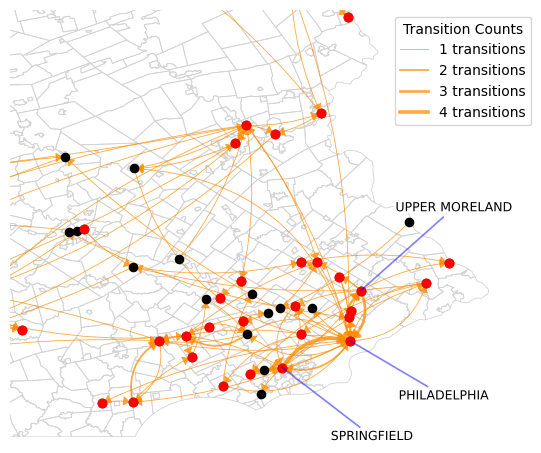

In [286]:
# --- Compute SE corner bounds from the full PA extent ---
minx, miny, maxx, maxy = muni_gdf.total_bounds
mid_x = (minx + maxx) / 2
mid_y = (miny + maxy) / 2

fig2, ax2 = plt.subplots(figsize=(5.5, 5.5))

# Base boundaries
muni_gdf.plot(ax=ax2, facecolor="none", edgecolor="lightgray", linewidth=0.6, zorder=1)

offsets_pts = {
    "108 | 23": (35, -45),
    "301 | 67": (35, -35),
    "110 | 46": (25, 55),
    #"221 | 14": (-35, -25),
    #"205 | 44": (-35, -25),
    "301 | 02": (35, -45),
    "301 | 36": (35, -45)
}


# Draw edges (same as original)
for (_, r), lw in zip(edge_counts_yes.iterrows(), lws):
    A = centroids.loc[r["from_id"]]
    B = centroids.loc[r["to_id"]]
    draw_arc_arrow(ax2, A["lon"], A["lat"], B["lon"], B["lat"],
                   lw=lw, rad=r["rad"], color="darkorange", alpha=0.75)

# Normal nodes
ax2.scatter(nodes["lon"], nodes["lat"], s=35, color="black", zorder=5)

# Highlighted (YES) nodes
ax2.scatter(highlight_nodes["lon"], highlight_nodes["lat"],
            s=35, color="red", linewidth=1.2, zorder=10)

# Labels (same targets dict)
for muni_id, label in targets.items():
    if muni_id not in centroids.index:
        continue
    lon = float(centroids.loc[muni_id, "lon"])
    lat = float(centroids.loc[muni_id, "lat"])
    dx, dy = offsets_pts.get(muni_id, (25, 20))
    ax2.annotate(label, xy=(lon, lat), xytext=(dx, dy),
                 textcoords="offset points",
                 ha="left" if dx >= 0 else "right",
                 va="bottom" if dy >= 0 else "top",
                 fontsize=9, zorder=20, path_effects=outline_effect,
                 arrowprops=dict(arrowstyle="-", lw=1.2, color="blue",
                                 alpha=0.5, shrinkA=0, shrinkB=0,
                                 connectionstyle="arc3,rad=0.0"))

# Legend
#ax2.legend(handles=legend_lines, title="Transition Counts",
#           loc="upper right", frameon=True)

ax2.legend(
    handles=legend_lines,
    title="Transition Counts",
    loc="upper right",
    bbox_to_anchor=(1.08, 1.0),  # shift right by changing first number
    frameon=True
)

# ── Zoom to SE corner ──────────────────────────────────────────────
#ax2.set_xlim(mid_x, maxx)
ax2.set_xlim((mid_x + maxx) / 2, maxx)
ax2.set_ylim(miny, mid_y)
# ──────────────────────────────────────────────────────────────────

ax2.set_aspect("equal")
ax2.set_axis_off()
plt.tight_layout()
plt.savefig("transitions_SE_corner.png", dpi=150)
plt.show()


## See distribution of number of reviews for these selected users

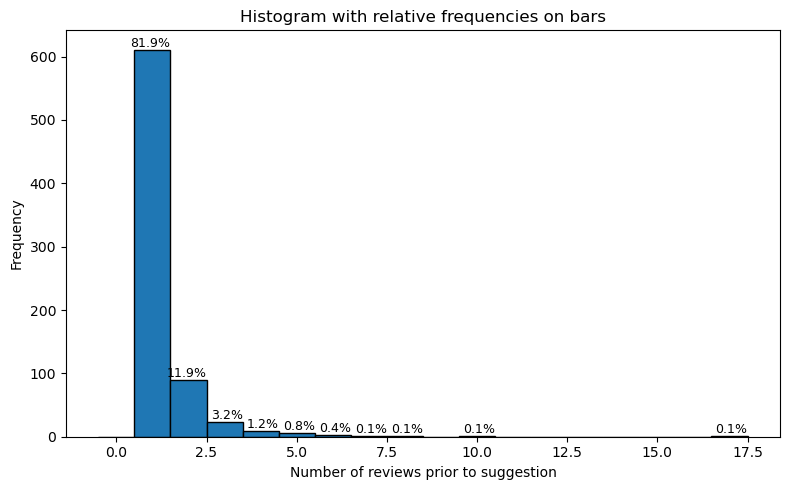

In [232]:

x = selected_users_reviews.groupby("review_user_id").size()


# 1-bin width
bins = np.arange(0, x.max()+2, 1)

plt.figure(figsize=(8,5))
counts, bin_edges, patches = plt.hist(
    x,
    bins=bins,
    edgecolor="black",
    align="left"
)

# total observations (for relative freq)
total = counts.sum()

# Add text above each bar
for count, left_edge in zip(counts, bin_edges):
    if count > 0:
        rel_freq = count / total
        plt.text(
            left_edge + 0.5,     # centered above bar
            count,               # height where text sits
            f"{rel_freq:.1%}",   # relative frequency
            ha="right",
            va="bottom",
            fontsize=9
        )

plt.xlabel("Number of reviews prior to suggestion")
plt.ylabel("Frequency")
plt.title("Histogram with relative frequencies on bars")
plt.tight_layout()
plt.show()

## See how many reviews selected users completed before their responded-to suggestion  

In [233]:
yes_suggest = labelled_reviews[labelled_reviews["final_label"] == "YES"].copy().sort_values(["review_user_id", "review_date"])

#yes_suggest["review_number"] = yes_suggest.groupby("review_user_id").cumcount()



In [234]:
# Pre-group all review dates by user for fast lookup
user_dates = {
    uid: grp["review_date"].dropna().values
    for uid, grp in reviews_geo.groupby("review_user_id")
}

In [235]:
# For each YES review, count how many reviews that user had strictly before it
yes_suggest["prior_review_count"] = [
    int((user_dates.get(row.review_user_id, np.array([])) < row.review_date).sum())
    for row in yes_suggest.itertuples()
]

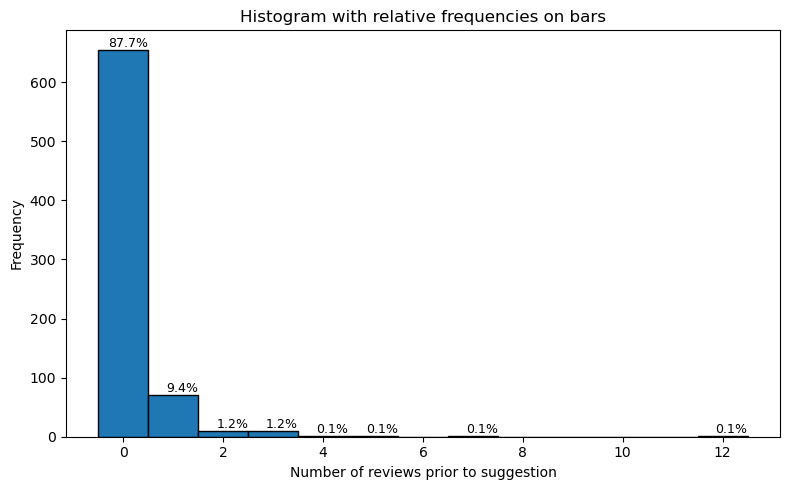

In [236]:


x = yes_suggest["prior_review_count"].dropna().astype(int)

# 1-bin width
bins = np.arange(0, x.max()+2, 1)

plt.figure(figsize=(8,5))
counts, bin_edges, patches = plt.hist(
    x,
    bins=bins,
    edgecolor="black",
    align="left"
)

# total observations (for relative freq)
total = counts.sum()

# Add text above each bar
for count, left_edge in zip(counts, bin_edges):
    if count > 0:
        rel_freq = count / total
        plt.text(
            left_edge + 0.5,     # centered above bar
            count,               # height where text sits
            f"{rel_freq:.1%}",   # relative frequency
            ha="right",
            va="bottom",
            fontsize=9
        )

plt.xlabel("Number of reviews prior to suggestion")
plt.ylabel("Frequency")
plt.title("Histogram with relative frequencies on bars")
plt.tight_layout()
plt.show()

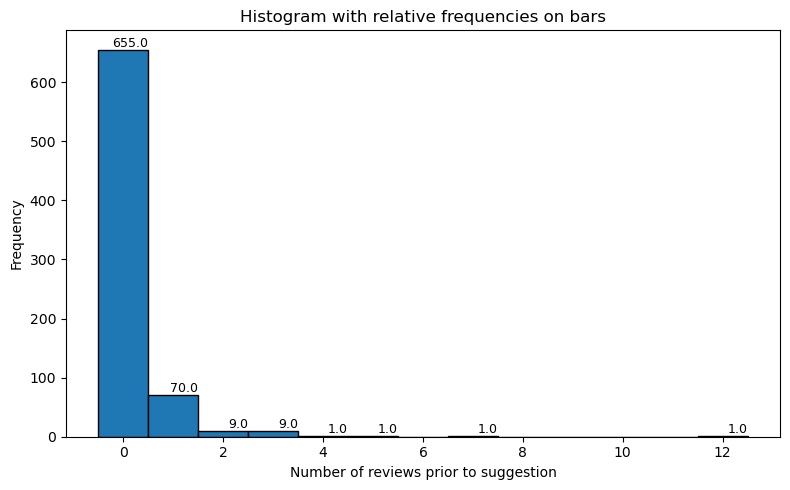

In [237]:


x = yes_suggest["prior_review_count"].dropna().astype(int)

# 1-bin width
bins = np.arange(0, x.max()+2, 1)

plt.figure(figsize=(8,5))
counts, bin_edges, patches = plt.hist(
    x,
    bins=bins,
    edgecolor="black",
    align="left"
)

# total observations (for relative freq)
total = counts.sum()

# Add text above each bar
for count, left_edge in zip(counts, bin_edges):
    if count > 0:
        #rel_freq = count / total
        plt.text(
            left_edge + 0.5,     # centered above bar
            count,               # height where text sits
            f"{count}",   # relative frequency
            ha="right",
            va="bottom",
            fontsize=9
        )

plt.xlabel("Number of reviews prior to suggestion")
plt.ylabel("Frequency")
plt.title("Histogram with relative frequencies on bars")
plt.tight_layout()
plt.show()

## See kinds of suggestions

In [264]:
print(yes_suggest.iloc[8, 2])


So I love this place and their pizza. But last night they randomly put a 15% gratuity on my check (party of 2) and of course I didn’t expect that so I tipped on the total anyway. Got home and realized why the bill was so high. Definitely my mistake but I bet I’m one of MANY people making it. This feels kind of shady. I’m all for servers making money and I always tip 20% or more. But it really feels like they tricked me into tipping 35%. And that’s not cool. Especially when I had to seat myself and order from a window (ie they didn’t really “serve” me much at all). Just a warning to everyone else to watch out for an auto tip at this place.


In [257]:

print(yes_suggest.iloc[5, 2])


Nice spot for lunch...but it looks like it needs a facelift. We went for lunch the day before Valentine's day, and it was a very sparse crowd. The service was very attentive and accomdating. Our food arrived promptly and efficiently. My chicken Caesar salad had some lovely moist chicken breast, but the croutons seemed to have come from a box, very uninspired. The shared starter of veggie lettuce wraps were spicy and delicious. Other menu items ordered were a Brewbin, hamburger salad, crab cake sandwich and fries. All of the dishes were tasty and well executed. It is pricey for lunch, with apparently the same dinner menu.
What I noticed during a trip to the Ladies Room was how shabby it looked. There were slate floor tiles which were cracked and loose near the servers station, the carpet (yuck) in the dining room was dirty, worn, and in need of replacing. The interior looks dated and the woodwork is nicked and worn. This has been such a solid spot in West Chester for so long. It looks l

In [259]:
print(yes_suggest.iloc[12, 2])


Beer was great but service could be more prompt. Overall a fun experience.
